# EXXA3 – Simulated Exoplanet Transit Detection

Author: Mitul Rishi  
B.Tech Computer Science – IIIT Kota

Transit photometry is one of the primary methods used to detect exoplanets.
When a planet passes in front of its host star, it produces a small dip in the observed brightness.

## Pipeline Overview

This notebook implements the following workflow:

1. Simulate stellar light curves containing transit signals
2. Generate a labeled dataset of planetary and non-planetary signals
3. Train a machine learning model to detect transits
4. Evaluate the classifier using accuracy and confusion matrix
5. Validate detection using injection-recovery experiments

The goal is to demonstrate a reproducible workflow for transit signal detection
using simulated astronomical data.

In [197]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

In [198]:
np.random.seed(42)

In [199]:
def simulate_transit(time, period, depth, duration):

    flux = np.ones_like(time)

    phase = (time % period) / period

    transit = np.abs(phase - 0.5) < duration / 2

    flux[transit] -= depth

    return flux

## Dataset Generation

In [200]:
def generate_dataset(n_samples=2000):

    X = []
    y = []

    for _ in range(n_samples):

        time = np.linspace(0,30,300)

        has_planet = np.random.rand() > 0.5

        if has_planet:

            period = np.random.uniform(2,10)
            depth = np.random.uniform(0.01,0.03)
            duration = np.random.uniform(0.05,0.1)

            flux = simulate_transit(time,period,depth,duration)

            y.append(1)

        else:

            flux = np.ones_like(time)
            y.append(0)

        flux += np.random.normal(0,0.001,len(time))

        X.append(flux)

    return np.array(X), np.array(y)

In [201]:
X,y = generate_dataset()

print(X.shape)

(2000, 300)


## Dataset Summary

Total samples: 2000

Time resolution: 300 observations per light curve

Class distribution:
- Planet transit signals
- Non-transit stellar light curves

Transit parameters sampled from:

• Orbital Period: 2–10 days  
• Transit Depth: 0.01–0.03  
• Transit Duration: 0.05–0.1

Gaussian noise with σ = 0.001 is added to simulate observational noise.

This synthetic dataset mimics simplified exoplanet transit observations used in photometric surveys such as Kepler and TESS.

## Parameter Distributions Analysis

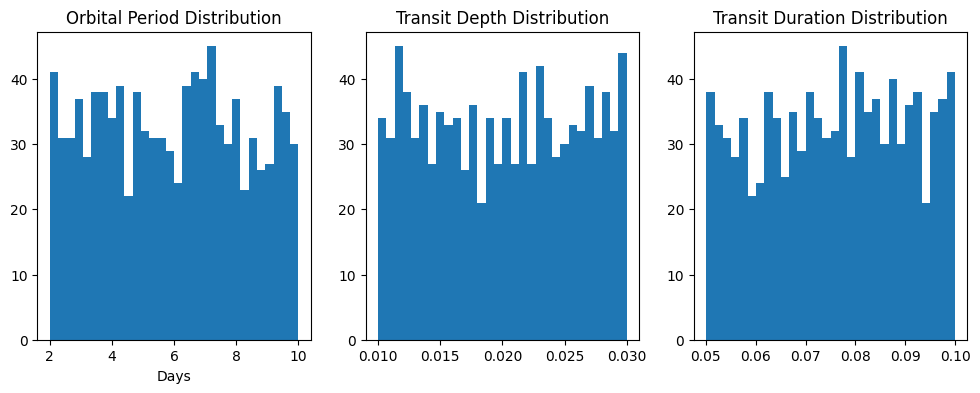

In [202]:
periods = []
depths = []
durations = []

for _ in range(1000):

    periods.append(np.random.uniform(2,10))
    depths.append(np.random.uniform(0.01,0.03))
    durations.append(np.random.uniform(0.05,0.1))

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.hist(periods,bins=30)
plt.title("Orbital Period Distribution")
plt.xlabel("Days")

plt.subplot(132)
plt.hist(depths,bins=30)
plt.title("Transit Depth Distribution")

plt.subplot(133)
plt.hist(durations,bins=30)
plt.title("Transit Duration Distribution")

plt.show()

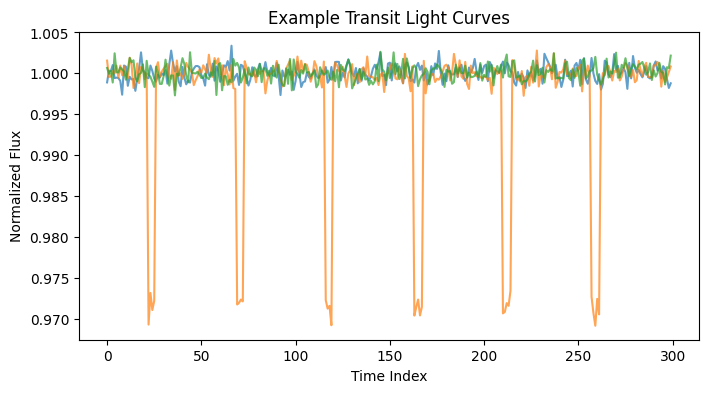

In [203]:
plt.figure(figsize=(8,4))

for i in range(3):
    
    plt.plot(X[i],alpha=0.7)

plt.title("Example Transit Light Curves")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")

plt.show()

## Phase Folding

In [204]:
def phase_fold(time,flux,period):

    phase = (time % period)/period
    idx = np.argsort(phase)

    return phase[idx], flux[idx]

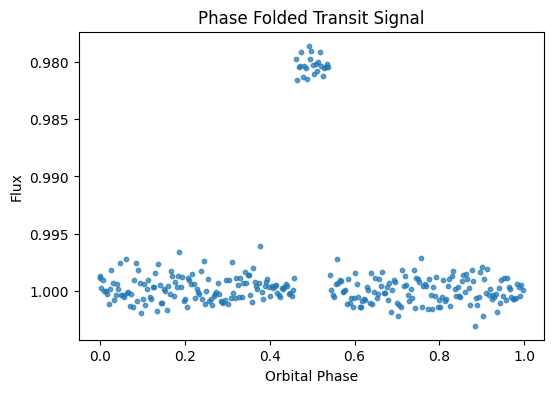

In [205]:
time = np.linspace(0,30,300)

flux = simulate_transit(time,5,0.02,0.08)

# add small noise
flux = flux + np.random.normal(0,0.001,len(time))

phase, folded_flux = phase_fold(time,flux,5)

plt.figure(figsize=(6,4))

plt.scatter(phase,folded_flux,s=10,alpha=0.7)

plt.title("Phase Folded Transit Signal")
plt.xlabel("Orbital Phase")
plt.ylabel("Flux")

plt.gca().invert_yaxis()

plt.show()

## Train/Test Split

In [206]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training (Random Forest)

In [207]:
model = RandomForestClassifier(n_estimators=200)

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Classification Report

In [208]:
pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       192
           1       1.00      1.00      1.00       208

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [209]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


## Confusion Matrix


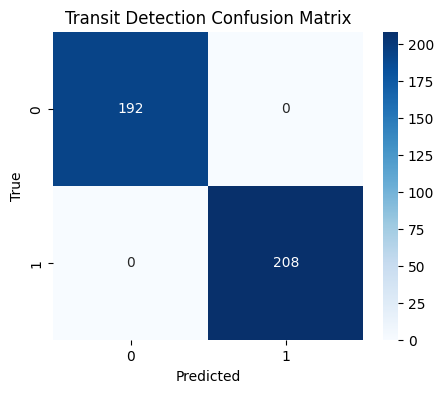

In [210]:
import seaborn as sns

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("Transit Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

## ROC Curve

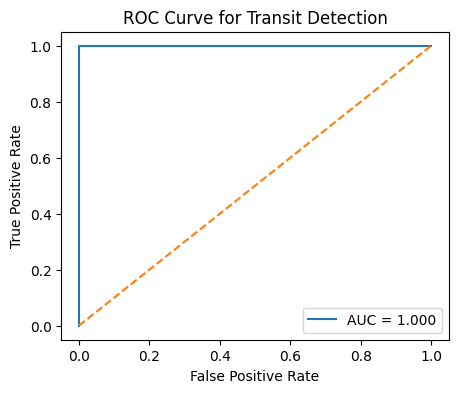

In [211]:
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,probs)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(5,4))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve for Transit Detection")

plt.legend()

plt.show()

## Model Prediction Confidence

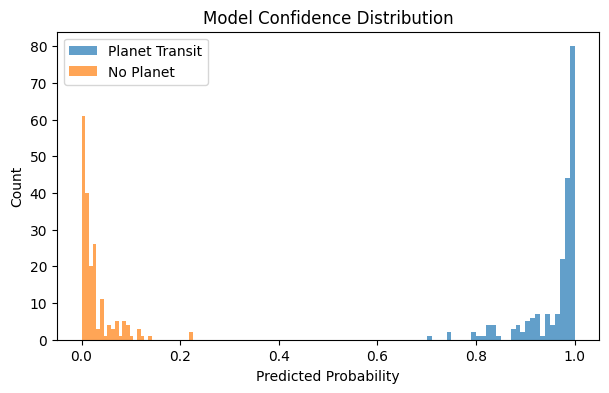

In [212]:
probs = model.predict_proba(X_test)[:,1]

plt.figure(figsize=(7,4))

plt.hist(probs[y_test==1], bins=30, alpha=0.7, label="Planet Transit")
plt.hist(probs[y_test==0], bins=30, alpha=0.7, label="No Planet")

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Model Confidence Distribution")

plt.legend()

plt.show()

## Signal-to-Noise Analysis

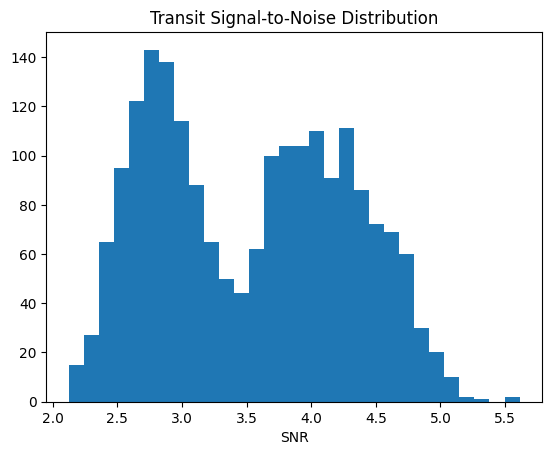

In [213]:
def compute_snr(signal):

    signal_depth = 1 - np.min(signal)
    noise = np.std(signal)

    return signal_depth / noise

snr_values = [compute_snr(x) for x in X]

plt.hist(snr_values,bins=30)

plt.title("Transit Signal-to-Noise Distribution")
plt.xlabel("SNR")

plt.show()

## Injection Recovery Test

In [214]:
test_time = np.linspace(0,30,300)

injected_flux = simulate_transit(test_time,7,0.02,0.08)

prediction = model.predict([injected_flux])

print("Injected planet detected:", prediction[0])

Injected planet detected: 1


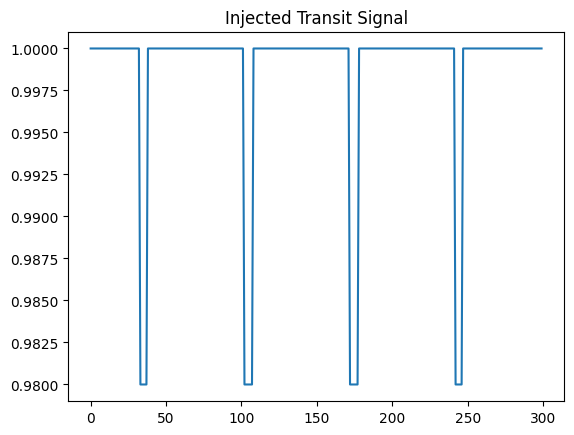

In [215]:
plt.plot(injected_flux)

plt.title("Injected Transit Signal")

plt.show()

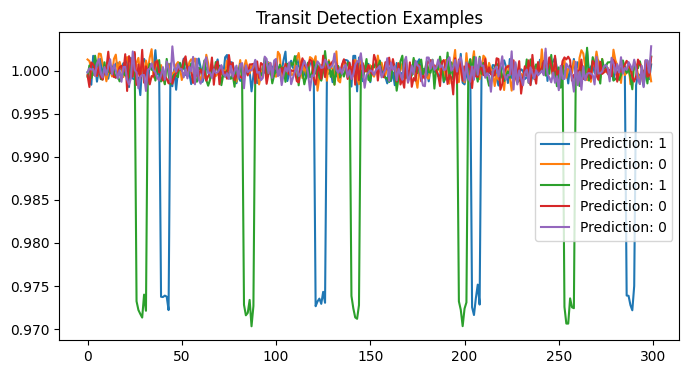

In [216]:
plt.figure(figsize=(8,4))

for i in range(5):

    plt.plot(X_test[i],label=f"Prediction: {pred[i]}")

plt.legend()

plt.title("Transit Detection Examples")

plt.show()

## Feature Importance

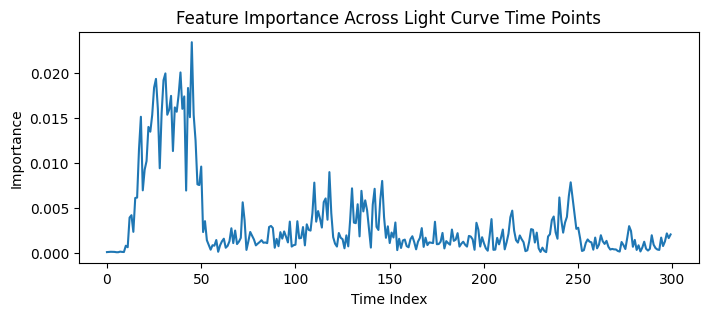

In [217]:
importance = model.feature_importances_

plt.figure(figsize=(8,3))

plt.plot(importance)

plt.title("Feature Importance Across Light Curve Time Points")

plt.xlabel("Time Index")
plt.ylabel("Importance")

plt.show()

## Pipeline Function

In [218]:
def run_pipeline():

    X,y = generate_dataset()

    X_train,X_test,y_train,y_test = train_test_split(
        X,y,test_size=0.2
    )

    model = RandomForestClassifier(n_estimators=200)

    model.fit(X_train,y_train)

    preds = model.predict(X_test)

    print(classification_report(y_test,preds))

## Discussion

The pipeline demonstrates a simplified workflow for detecting
exoplanet transit signals using machine learning.

The simulated dataset includes variability in orbital period,
transit depth, and duration, which enables the model to learn
generalizable patterns.

Future work could incorporate:

• convolutional neural networks  
• recurrent neural networks for sequential analysis  
• real Kepler or TESS datasets  

These approaches would further improve the robustness of transit detection models.